In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
import os
from PIL import Image



In [2]:
PATH = 'C:/Users/Пользователь/Desktop/програмироание/frukta'
TRAIN_PATH = PATH + '/train'
TEST_PATH = PATH + '/test'

In [3]:
# Преобразования для изображений
transform = transforms.Compose([
    transforms.ToTensor(),
])

ИЛИ # Преобразования для изображений
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация
])

In [6]:
# Загрузка обучающей выборки (с подпапками классов)
train_dataset = ImageFolder(root=TRAIN_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [7]:
# Классы (фрукты, овощи, ягоды)
class_names = train_dataset.classes
print("Классы:", class_names)

Классы: ['berrie', 'fruits', 'vegeta']


In [8]:
# Определение архитектуры нейронной сети
class Net(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)  # 3 канала цветов Добавлен padding=1 чтобы не терять информацию
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)  # ядро свёртки 3 на 3
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()#Функция активации, которая возвращает max(0, x). Она нелинейная и помогает модели изучать сложные зависимости
        self.fc1 = nn.Linear(64 * 25 * 25, 100)  # Изменён размер входного слоя
        self.fc2 = nn.Linear(100, num_classes)

    def forward(self, x):
        x = self.relu(self.pool(self.conv1(x)))  # После conv1 и pool: (32, 50, 50)
        x = self.relu(self.pool(self.conv2(x)))  # После conv2 и pool: (64, 25, 25)
        x = x.view(x.size(0), -1)  # Выравниваем данные
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [10]:
# Распределение классов в обучающей выборке
class_distribution = pd.Series(train_dataset.targets).value_counts().reset_index()
class_distribution.columns = ['Class', 'Count']
class_distribution['Class'] = class_distribution['Class'].apply(lambda x: class_names[x])


In [11]:

# График распределения классов
px.bar(class_distribution, x='Class', y='Count', title='Распределение классов в обучающей выборке').show()

In [12]:
# Функция для отображения изображений
def display_images(images, labels, class_names, n=10):
    rows, cols = 1, n
    fig = plt.figure(figsize=(15, 3))
    for i in range(n):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        ax.set_title(class_names[labels[i]])
        ax.axis('off')
    plt.show()



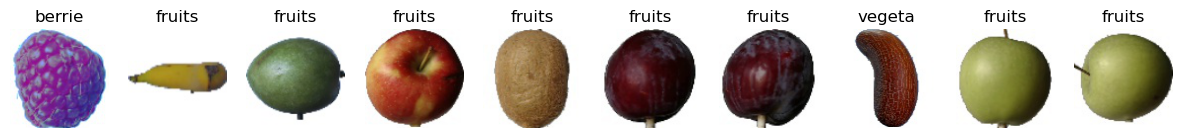

In [13]:
# Отображение первых 10 изображений из обучающей выборки
images, labels = next(iter(train_loader))
display_images(images, labels, class_names, n=10)

In [14]:
EPOCHS = 5
train_losses = []
net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = Adam(net.parameters(), lr=0.001)

эпохи вариант один.

In [ ]:
#for epoch in range(EPOCHS):
#    net.train()
#    running_loss = 0.0
#    for images, labels in train_loader:
#        optimizer.zero_grad()
#        outputs = net(images)
#        loss = criterion(outputs, labels)
#        loss.backward()
#        optimizer.step()
#        running_loss += loss.item()
#        epoch_loss = running_loss / len(train_loader)
#        train_losses.append(epoch_loss)
#    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.15832823054304093
Epoch 2, Loss: 0.00693041302629078
Epoch 3, Loss: 0.002943175936087011
Epoch 4, Loss: 0.0027968143907404546
Epoch 5, Loss: 8.91177191402731e-05


эпохи второй вариан

In [15]:
for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0  # Для суммирования потерь за эпоху

    for data in train_loader:
        # Получаем данные
        X_train, y_train = data

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        y_pred = net(X_train)

        # Вычисляем потери
        train_loss = criterion(y_pred, y_train)

        # Обратный проход и оптимизация
        train_loss.backward()
        optimizer.step()

        # Суммируем потери
        running_loss += train_loss.item()

    # Вычисляем среднюю потерю за эпоху
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss) # добавляем *после* завершения эпохи

    # Выводим средние потери за эпоху
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss}")

Epoch 1, Loss: 0.11508291922059884
Epoch 2, Loss: 0.0015571022335638136
Epoch 3, Loss: 0.00021829129801779234
Epoch 4, Loss: 7.596309670575327e-05
Epoch 5, Loss: 4.206699524081959e-05


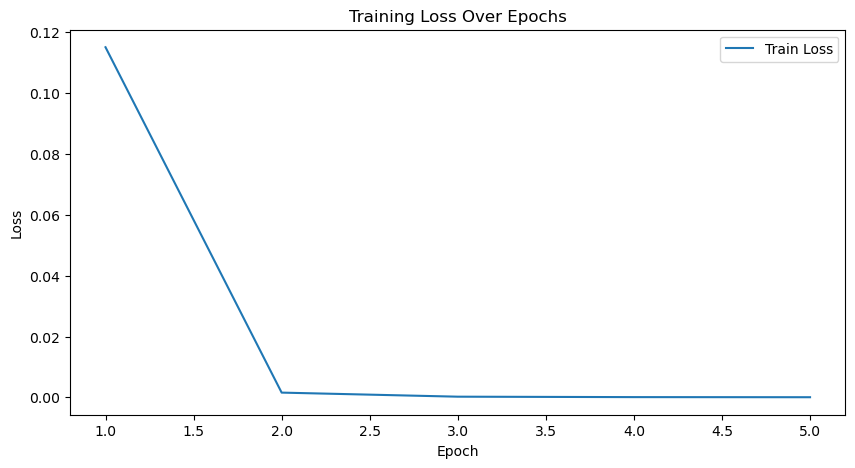

In [16]:
# График потерь
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, EPOCHS + 1), y=train_losses, label='Train Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [17]:
# Функция для загрузки изображений из папки (без подпапок)
def load_test_images(folder, transform):
    images = []
    image_paths = []
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        try:
            image = Image.open(image_path).convert('RGB')  # Открываем изображение и конвертируем в RGB
            image = transform(image)  # Применяем преобразования
            images.append(image)
            image_paths.append(image_path)
        except Exception as e:
            print(f"Ошибка при загрузке изображения {image_path}: {e}")
    return torch.stack(images), image_paths  # Возвращаем тензор изображений и пути к ним
# Загрузка тестовых изображений
test_images, test_image_paths = load_test_images(TEST_PATH, transform)

In [18]:
# Тестирование модели на обучающей выборке (для оценки точности)
net.eval()
correct = 0
total = 0
predicted_labels = []
true_labels = []
with torch.no_grad():
    for images, labels in train_loader:
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        predicted_labels.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(f'Test Accuracy on Train Set: {100 * correct / total}%')




Test Accuracy on Train Set: 100.0%


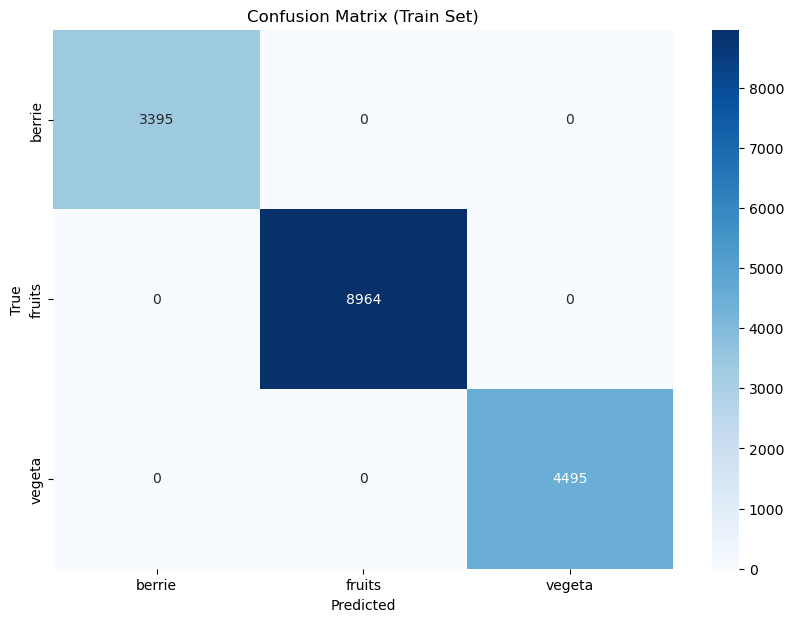

In [19]:
# Матрица ошибок для обучающей выборки
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predicted_labels)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Train Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [20]:
# Создание собственного Dataset для тестовой выборки (без подпапок классов)
class TestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.image_files = [f for f in os.listdir(root) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name  # Возвращаем изображение и имя файла



In [21]:
# Загрузка тестовой выборки
test_dataset = TestDataset(root=TEST_PATH, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [22]:
# Визуализация тестовой выборки (без меток)
def display_test_images(images, filenames, n=5):
    rows, cols = 1, n
    fig = plt.figure(figsize=(15, 3))
    for i in range(n):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        ax.set_title(filenames[i])
        ax.axis('off')
    plt.show()



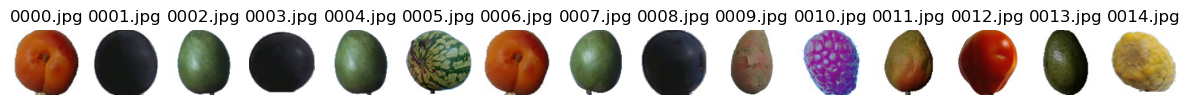

In [23]:
# Отображение первых 15 изображений из тестовой выборки
test_images, test_filenames = next(iter(test_loader))
display_test_images(test_images, test_filenames, n=15)

In [24]:
# Визуальное тестирование модели
net.eval()
with torch.no_grad():
    outputs = net(test_images)
    _, predicted = torch.max(outputs, 1)



In [25]:
# Отображение результатов
def display_predictions(images, paths, predictions, class_names):
    plt.figure(figsize=(15, 10))
    for i in range(min(len(images), 10)):  # Показываем первые 12 изображений
        plt.subplot(3, 4, i + 1)
        image = images[i].permute(1, 2, 0).numpy()  # Преобразуем тензор в изображение
        #image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Обратная нормализация
        image = np.clip(image, 0, 1)  # Ограничиваем значения до [0, 1]
        plt.imshow(image)
        plt.title(f"Pred: {class_names[predictions[i]]}")
        plt.axis('off')
    plt.show()



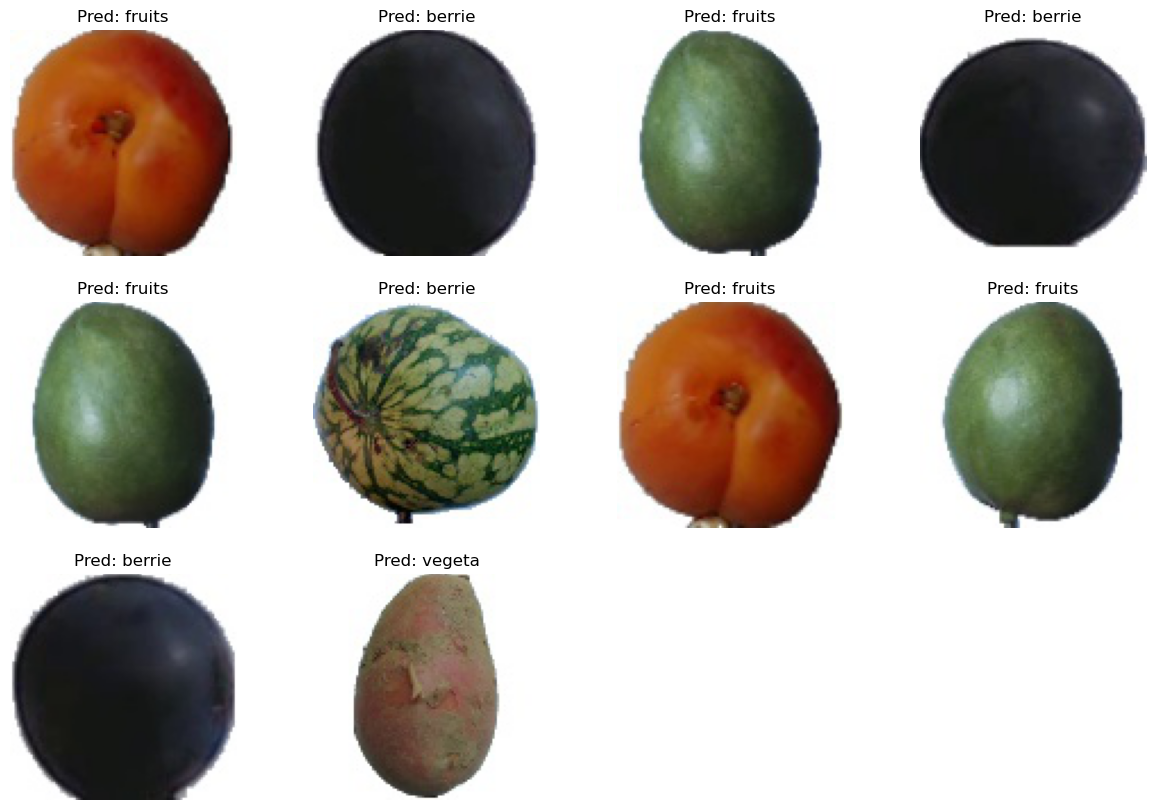

In [26]:
# Выводим результаты
display_predictions(test_images, test_image_paths, predicted, class_names)

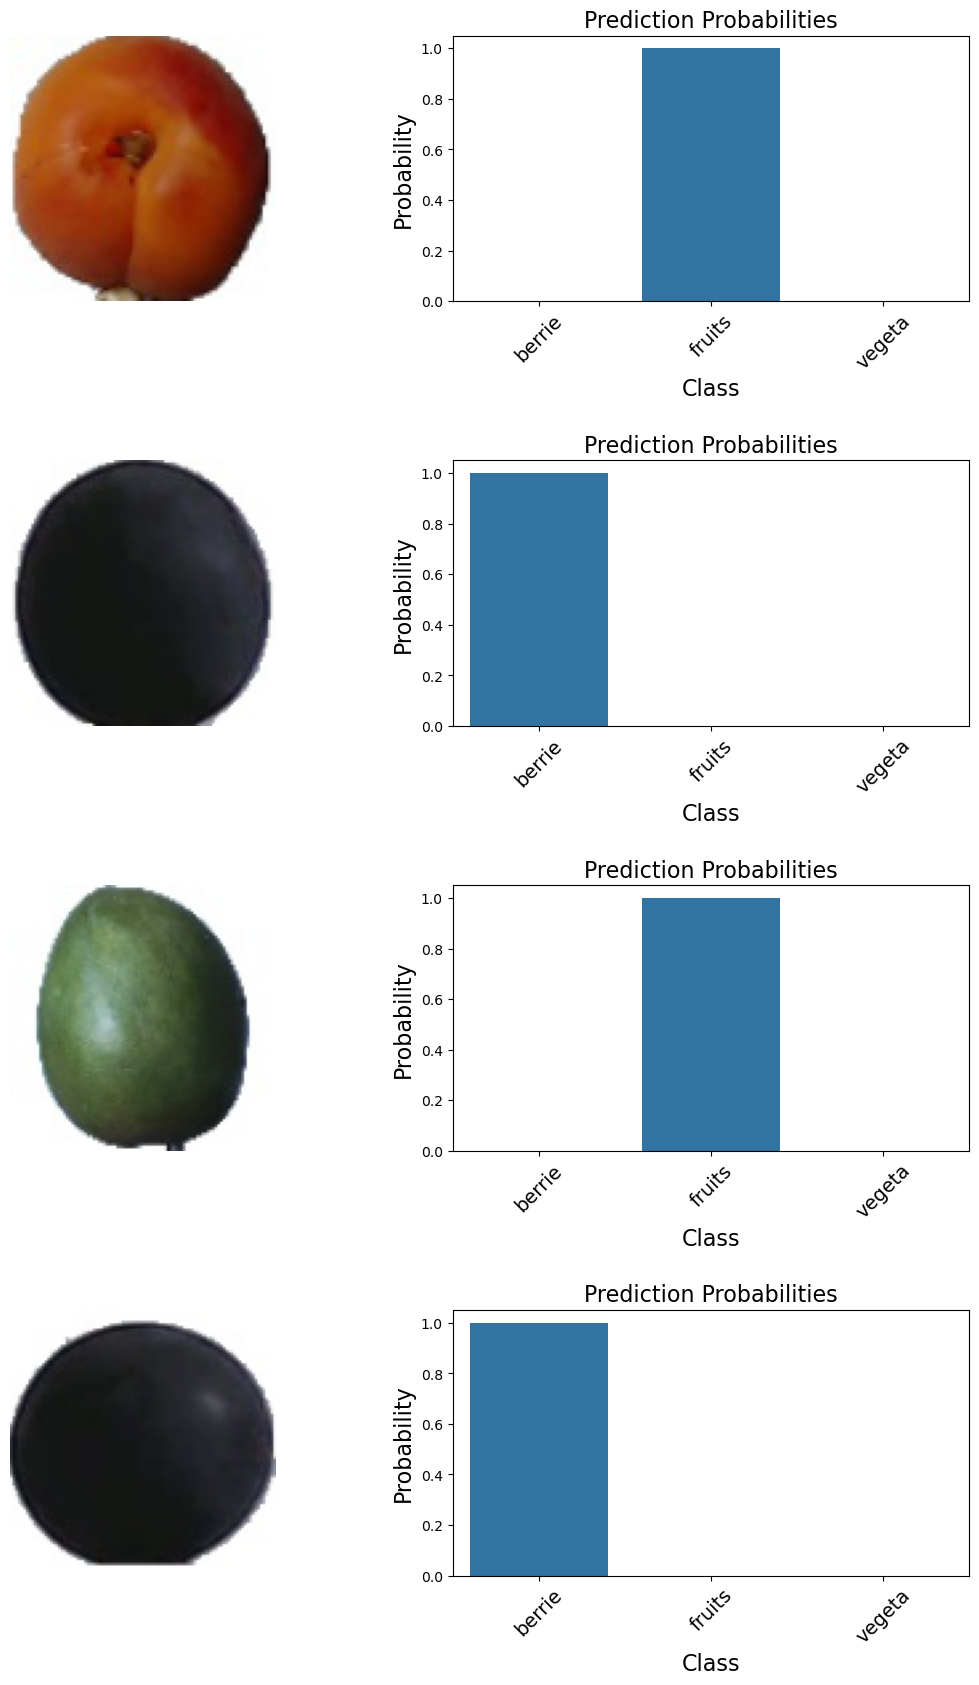

In [27]:
# График вероятностей для нескольких изображений
def display_probabilities_for_images(images, outputs, class_names, n=4):
    plt.figure(figsize=(14, 20))
    for i in range(n):
        plt.subplot(4, 2, 2 * i + 1)
        image = images[i].permute(1, 2, 0).numpy()
        #image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        image = np.clip(image, 0, 1)
        plt.imshow(image)
        plt.title("")
        plt.axis('off')

        plt.subplot(4, 2, 2 * i + 2)
        probs = torch.exp(outputs[i]).detach().numpy()
        sns.barplot(x=class_names, y=probs)
        plt.title("Prediction Probabilities", fontsize=16)
        plt.xlabel("Class", fontsize=16)
        plt.ylabel("Probability", fontsize=16)
        plt.xticks(fontsize=14, rotation=45)
    plt.subplots_adjust(hspace=0.6, wspace=0.1)
    plt.show()

display_probabilities_for_images(test_images, outputs, class_names, n=4)

In [28]:
def generate_image_for_class(model, target_class, image_size=(100, 100), num_iterations=1000, lr=0.01):
    """
    Генерирует изображение, которое максимизирует активацию определённого класса.

    :param model: Обученная модель.
    :param target_class: Индекс целевого класса.
    :param image_size: Размер изображения (H, W).
    :param num_iterations: Количество итераций оптимизации.
    :param lr: Скорость обучения.
    :param device: Устройство (CPU или GPU).
    :return: Сгенерированное изображение.
    """
    # Создаём изображение с белым фоном (значения 1.0)
    image = torch.ones(1, 3, *image_size, requires_grad=True)  # (batch_size, channels, height, width)

    # Оптимизатор для обновления изображения
    optimizer = torch.optim.Adam([image], lr=lr)

    for i in range(num_iterations):
        optimizer.zero_grad()

        # Прогоняем изображение через модель
        output = model(image)

        # Вычисляем потерю (минимизируем отрицательную активацию целевого класса)
        loss = -output[0, target_class]  # Минус, потому что мы хотим максимизировать активацию

        # Обратное распространение
        loss.backward()

        # Обновляем изображение
        optimizer.step()

        # Ограничиваем значения пикселей в диапазоне [0, 1]
        with torch.no_grad():
            image.clamp_(0, 1)

        if (i + 1) % 100 == 0:
            print(f"Iteration {i + 1}, Loss: {loss.item()}")

    return image.detach()


In [29]:
# Генерация изображений для каждого класса
class_names = ['fruits', 'vegetables', 'berries']
generated_images = []




In [30]:
net.eval()  # Переводим модель в режим оценки (evaluation)
for class_idx, class_name in enumerate(class_names):
    print(f"Generating image for class: {class_name}")
    generated_image = generate_image_for_class(net, class_idx)  # Используем обученную модель net и передаем device
    generated_images.append(generated_image)


Generating image for class: fruits
Iteration 100, Loss: 2.3841855067985307e-07
Iteration 200, Loss: 2.3841855067985307e-07
Iteration 300, Loss: 2.3841855067985307e-07
Iteration 400, Loss: 2.3841855067985307e-07
Iteration 500, Loss: 2.3841855067985307e-07
Iteration 600, Loss: 2.3841855067985307e-07
Iteration 700, Loss: 2.3841855067985307e-07
Iteration 800, Loss: 2.3841855067985307e-07
Iteration 900, Loss: 2.3841855067985307e-07
Iteration 1000, Loss: 2.3841855067985307e-07
Generating image for class: vegetables
Iteration 100, Loss: -0.0
Iteration 200, Loss: -0.0
Iteration 300, Loss: -0.0
Iteration 400, Loss: -0.0
Iteration 500, Loss: -0.0
Iteration 600, Loss: -0.0
Iteration 700, Loss: -0.0
Iteration 800, Loss: -0.0
Iteration 900, Loss: -0.0
Iteration 1000, Loss: -0.0
Generating image for class: berries
Iteration 100, Loss: 2.3841855067985307e-07
Iteration 200, Loss: 2.3841855067985307e-07
Iteration 300, Loss: 2.3841855067985307e-07
Iteration 400, Loss: 2.3841855067985307e-07
Iteration 50

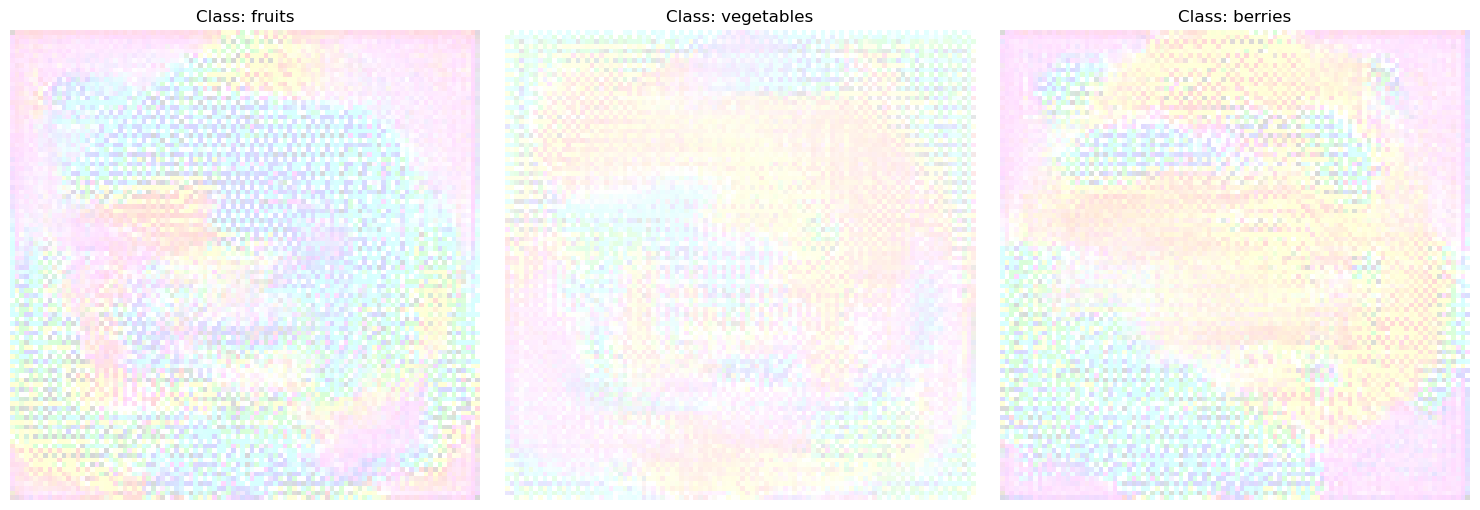

In [31]:
# Отрисовка сгенерированных изображений
def display_generated_images(generated_images, class_names):
    fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5))
    for i, (image, class_name) in enumerate(zip(generated_images, class_names)):
        # Преобразуем тензор в numpy и меняем порядок осей
        image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(image, cmap='gray' if image.shape[-1] == 1 else None)
        axes[i].set_title(f"Class: {class_name}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Отображаем сгенерированные изображения
display_generated_images(generated_images, class_names)